sasho beshe tuk

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import scipy.stats as stats

In [4]:
df_sightings = pd.read_csv('./Phalacrocorax carbo.csv',sep=',', low_memory=False)
df_habitats = pd.read_csv('./habitats_cbs_2022.csv', sep=',', low_memory=False)

df = df_sightings.merge(
    df_habitats,
    on=["decimalLatitude", "decimalLongitude"],
    how="inner",
)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Phalacrocorax carbo        str    
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: float64(11), int64(1), str(3)
memory usage: 1.4 GB


In [6]:
pd.to_datetime(df['eventDate'])
cols = [
    "total_observations",
    "speciesgroup_observations",
    "Phalacrocorax carbo"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

In [7]:
# df.to_csv('bird_and_habitats.csv', index=False)

In [8]:
print(df.dtypes)

decimalLatitude              float64
decimalLongitude             float64
eventDate                        str
total_observations           float64
speciesgroup_observations      int64
Phalacrocorax carbo            int64
agricultural                 float64
built                        float64
coast                        float64
forest                       float64
other                        float64
sand/heather                 float64
water                        float64
wetland                      float64
main_habitat                     str
dtype: object


In [9]:
# --- convert to numeric ---
cols = [
    "total_observations",
    "speciesgroup_observations",
    "Phalacrocorax carbo"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# --- keep valid coordinates ---
df_clean = df.dropna(subset=["decimalLatitude", "decimalLongitude"])

# --- effort adjustment (important step) ---
df_clean["adjusted_weight"] = (
    df_clean["Phalacrocorax carbo"] /
    (df_clean["total_observations"] + df_clean["speciesgroup_observations"] + 1)
)

In [10]:
grouped = df_clean.groupby(
    ["decimalLatitude", "decimalLongitude"],
    as_index=False
)["adjusted_weight"].sum()

grouped = grouped[grouped["adjusted_weight"] > 5]

In [11]:
heat_data = grouped.values.tolist()

m = folium.Map(location=[52.1, 5.3], zoom_start=7)

HeatMap(
    heat_data,
    radius=20,
    blur=15,
    min_opacity=0.1,
    max_zoom=12
).add_to(m)

m.save("heatmap.html")

In [12]:
# Check for missing data
print("Missing values per column:")
print(df_clean.isnull().sum())

# Check distribution
print("\nTarget Variable Summary Statistics:")
print(df_clean['Phalacrocorax carbo'].describe())

# Check if any records are out of the Netherlands
out_of_bounds = df_clean[
    (df_clean['decimalLatitude'] < 50.5) | (df_clean['decimalLatitude'] > 53.7) |
    (df_clean['decimalLongitude'] < 3.2) | (df_clean['decimalLongitude'] > 7.2)
]
print(f"\nNumber of records outside the Netherlands: {len(out_of_bounds)}")

Missing values per column:
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Phalacrocorax carbo          0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
adjusted_weight              0
dtype: int64

Target Variable Summary Statistics:
count    1.255876e+07
mean     5.143431e-02
std      3.364980e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.090000e+02
Name: Phalacrocorax carbo, dtype: float64

Number of records outside the Netherlands: 0


## Data Quality
- There are zero missing values in the dataset across all columns and that confirms that all lat/long coordinates are well bounded inside the Netherlands (50.5 to 53.7 N, 3.2 to 7.2E)

In [13]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Feature engineering
df_clean['eventDate'] = pd.to_datetime(df_clean['eventDate'])
df_clean['month'] = df_clean['eventDate'].dt.month
df_clean['day_of_year'] = df_clean['eventDate'].dt.dayofyear
df_clean['is_breeding_season'] = df_clean['month'].isin([3, 4, 5, 6]).astype(int) # March-June

# Fill missing habitat with 0
habitat_cols = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']
df_clean[habitat_cols] = df_clean[habitat_cols].fillna(0)

# Convert 'main_habitat' string to integers
le = LabelEncoder()
df_clean['main_habitat_encoded'] = le.fit_transform(df_clean['main_habitat'].astype(str))

# Drop columns we won't pass directly into the model
features = [
    'decimalLatitude', 'decimalLongitude', 'month', 'day_of_year', 'is_breeding_season',
    'total_observations', 'speciesgroup_observations',
    'agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland',
    'main_habitat_encoded'
]

X = df_clean[features]
y = df_clean['adjusted_weight']

print("Data shape ready for modeling:", X.shape)

Data shape ready for modeling: (12558756, 16)


### Duplicate check

In [14]:
duplicates = df_clean.duplicated(subset=['decimalLatitude', 'decimalLongitude', 'eventDate']).sum()
print(f"Duplicate rows (same location + date): {duplicates}")
print(f"Total rows: {len(df_clean):,}")

Duplicate rows (same location + date): 0
Total rows: 12,558,756


Checks whether the same grid cell was recorded twice on the same day - that would be a data collection error worth flagging.

In [ ]:
sighted_count = (df_clean['Phalacrocorax carbo'] > 0).sum()
not_sighted_count = (df_clean['Phalacrocorax carbo'] == 0).sum()
total = len(df_clean)

print(f"Sighted: {sighted_count} | Not Sighted: {not_sighted_count} | Total: {total}")

Sighted: 459897 | Not Sighted: 12098859 | Total: 12558756


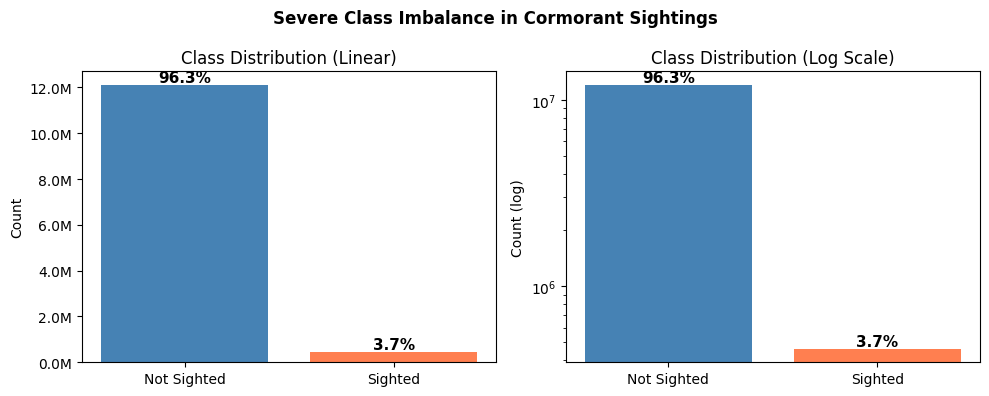

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Linear scale (raw counts)
axes[0].bar(['Not Sighted', 'Sighted'], [not_sighted_count, sighted_count], color=['steelblue', 'coral'])
axes[0].set_title('Class Distribution (Linear)')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Log scale (makes the imbalance readable)
axes[1].bar(['Not Sighted', 'Sighted'], [not_sighted_count, sighted_count], color=['steelblue', 'coral'])
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_ylabel('Count (log)')


for ax in axes:
    for bar, count in zip(ax.patches, [not_sighted_count, sighted_count]):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Severe Class Imbalance in Cormorant Sightings', fontweight='bold')
plt.tight_layout()
plt.show()

This is important to flag - cormorant sightings are rather rare ~3.7% which directly affects the model choice and metric selection.

### Target Distribution & Zero-Inflation
This cell measures how skewed our data is. It calculates:
* **Skewness Coefficient:** Measures the asymmetry of the distribution. A high positive value confirms massive bird spikes.
* **Zero-Inflation Proportion:** Calculates the exact percentage of rows where no cormorants were seen.

In [25]:
# Calculate skewness
raw_skew = stats.skew(df_clean['Phalacrocorax carbo'])
print(f"Fisher-Pearson Skewness coefficient of raw counts: {raw_skew:.2f}")

# Calculate the precise zero-inflation threshold percentage
zero_percentage = (not_sighted_count / total) * 100
print(f"Zero-Inflation Proportion: {zero_percentage:.2f}% of rows are zero.")

Fisher-Pearson Skewness coefficient of raw counts: 22.31
Zero-Inflation Proportion: 96.34% of rows are zero.


### Summary

The results isolated three critical characteristics that define our data quality and our modeling strategy:

* **0 Duplicates:** A duplicate check tracking coordinate pairs (`decimalLatitude`, `decimalLongitude`) against calendar timestamps (`eventDate`) returned zero repeated records. This confirms excellent collection and guarantees that our train/test validation design will not suffer from data leakage.
* **Class Imbalance (~3.7% Sighted):** Splitting the target variable (*Phalacrocorax carbo*) into a binary sighting indicator revealed that cormorants are present in only 459,897 records, while remaining absent in 12,098,859 records. This 3.7% class balance explains why a naive baseline classifier achieves a misleadingly high 96.3% accuracy rate by simply predicting zero everywhere.
* **Extreme Distribution Skewness & Zero-Inflation:** The dataset exhibits a Fisher-Pearson Skewness coefficient of **22.31** and a precise zero-inflation metric of **96.34%**. A skewness score this high mathematically proves that standard regression models (which assume a symmetric normal distribution) are fundamentally invalid for this task.

## Data preparation
- Converted the timestamp into cyclical indicators (`month`, `day_of_year`) and engineered a domain-specific binary flag (`is_breeding_season`) based on the March-June window.
- Used a `LabelEncoder` to cast the text column `main_habitat` into a numerical integer mapping (`main_habitat_encoded`) and isolated a clean feature matrix `X` alongside the target variable `y`

## Choosing a model and metrics
### Random Forest
- The tree erxhitrecture can pick up non-linear environmental conjstraints (If near water AND it is breeding season, then bird density spikes)

### Metrics
Since the data is mostly zeros, standart metrics like Mean Absolute Error (MAE) or R2 are not a good choice. A model that predicts that exactly 0 everywhere will get a seemingly great error score but provide zero real utility. For this dataset we can use:

- *Mean Tweedie Deviance* - Measures goodness of fit for zero-heavy continuous distributions.
- *Root Mean Squared Log Error (RMSLE)* - Since the maximum counts spike to 109, log errors penalize massive underpredictions well without blowing up the metric due to variance.

### Step 1: Create Features

In [ ]:
# Create binary sighted target for classification
df_clean['sighted'] = (df_clean['Phalacrocorax carbo'] > 0).astype(int)

print(f"Sightings: {(df_clean['sighted'] == 1).sum()}")
print(f"No sightings: {(df_clean['sighted'] == 0).sum()}")
print(f"Class balance: {df_clean['sighted'].mean()*100:.1f}% positive")

Sightings: 459897
No sightings: 12098859
Class balance: 3.7% positive


### Step 2: Prepare Data

In [ ]:
# Select simple features
baseline_features = ['decimalLatitude', 'decimalLongitude', 'month', 'day_of_year']

df_baseline = df_clean[baseline_features + ['sighted']].dropna()
print(f"Dataset size: {df_baseline.shape[0]:,} rows")

X_b = df_baseline[baseline_features]
y_b = df_baseline['sighted']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Dataset size: 12,558,756 rows
Train: 10,047,004 | Test: 2,511,752


### Step 3: Train Model

In [ ]:
# Train decision tree (max_depth=5 keeps it simple and interpretable)
model = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=20)
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


### Step 4: Evaluate Performance

In [ ]:
print("=" * 50)
print("TRAINING SET")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Precision: {precision_score(y_train, y_pred_train):.3f}")
print(f"Recall:    {recall_score(y_train, y_pred_train):.3f}")
print(f"F1-Score:  {f1_score(y_train, y_pred_train):.3f}")

print("\n" + "=" * 50)
print("TEST SET")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_test):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test):.3f}")

TRAINING SET
Accuracy:  0.963


/home/Sasho/HZYear2/Python/cormorant/the-greatest-cormorant/cormorant/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.000
Recall:    0.000
F1-Score:  0.000

TEST SET
Accuracy:  0.963


/home/Sasho/HZYear2/Python/cormorant/the-greatest-cormorant/cormorant/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.000
Recall:    0.000
F1-Score:  0.000


### Step 5: Visualize Results

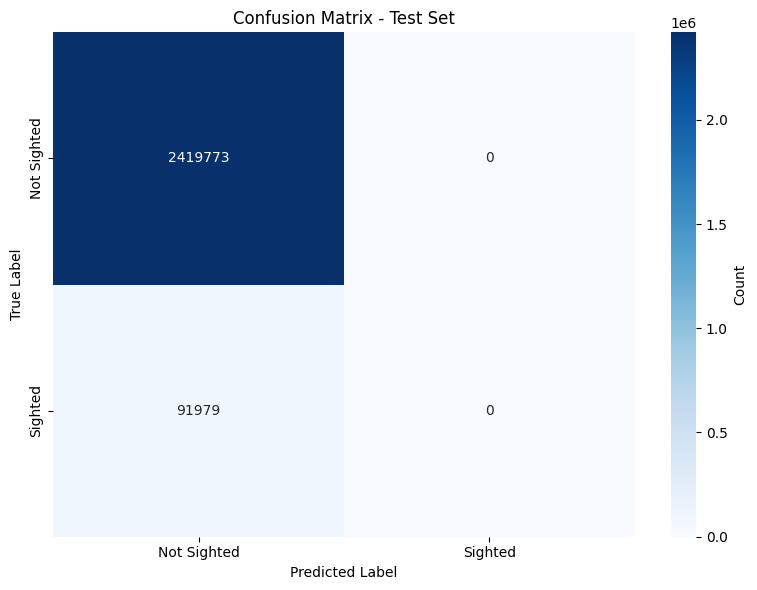

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sighted', 'Sighted'],
            yticklabels=['Not Sighted', 'Sighted'],
            cbar_kws={'label': 'Count'})
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()